In [3]:
# ============================================
# 美股科技巨头股票与财务分析
# 数据来源: WRDS (CRSP + Compustat)
# ============================================

import wrds
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 连接WRDS
db = wrds.Connection()
print("WRDS连接成功！")

# 定义股票代码 (PERMNO)
stocks = {
    'AAPL': 14593,  # Apple
    'MSFT': 10107,  # Microsoft
    'GOOGL': 14542  # Google (Alphabet)
}

# 获取2023-2025年的股票数据
query = """
SELECT date, permno, prc, ret, vol
FROM crsp.dsf
WHERE permno IN (14593, 10107, 14542)
AND date >= '2023-01-01'
ORDER BY date, permno
"""

df_stock = db.raw_sql(query, date_cols=['date'])
print(f"获取数据: {len(df_stock)} 条记录")
print(df_stock.head(10))

Loading library list...
Done
WRDS连接成功！
获取数据: 1506 条记录
        date  permno        prc       ret          vol
0 2023-01-03   10107     239.58 -0.001001   25723760.0
1 2023-01-03   14542       89.7  0.010932   20710597.0
2 2023-01-03   14593     125.07 -0.037405  111953221.0
3 2023-01-04   10107  229.10001 -0.043743   50564994.0
4 2023-01-04   14542      88.71 -0.011037   26980137.0
5 2023-01-04   14593     126.36  0.010314   89022192.0
6 2023-01-05   10107     222.31 -0.029638   39541865.0
7 2023-01-05   14542      86.77 -0.021869   23110412.0
8 2023-01-05   14593     125.02 -0.010605   81128113.0
9 2023-01-06   10107  224.92999  0.011785   43569634.0


In [4]:
# 添加股票名称列
permno_to_name = {14593: 'AAPL', 10107: 'MSFT', 14542: 'GOOGL'}
df_stock['ticker'] = df_stock['permno'].map(permno_to_name)

# 查看数据
print(df_stock.head())

        date  permno        prc       ret          vol ticker
0 2023-01-03   10107     239.58 -0.001001   25723760.0   MSFT
1 2023-01-03   14542       89.7  0.010932   20710597.0  GOOGL
2 2023-01-03   14593     125.07 -0.037405  111953221.0   AAPL
3 2023-01-04   10107  229.10001 -0.043743   50564994.0   MSFT
4 2023-01-04   14542      88.71 -0.011037   26980137.0  GOOGL


Loading library list...
Done


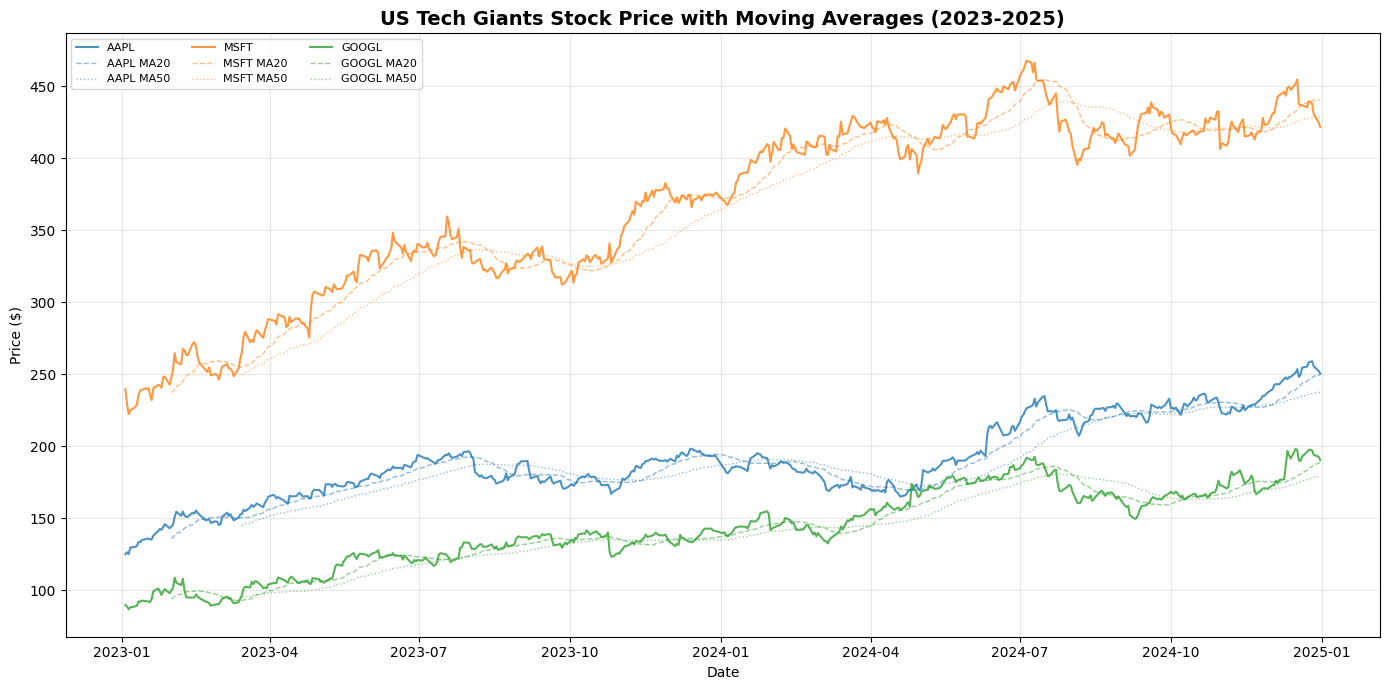

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

conn = wrds.Connection()

permno_dict = {'AAPL': 14593, 'MSFT': 10107, 'GOOGL': 14542}
colors = {'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c'}

all_data = {}
for symbol, permno in permno_dict.items():
    query = f"""
    SELECT date, prc as price
    FROM crsp.dsf
    WHERE permno = {permno} AND date BETWEEN '2023-01-01' AND '2025-03-31'
    ORDER BY date
    """
    all_data[symbol] = conn.raw_sql(query, date_cols=['date'])

fig, ax = plt.subplots(figsize=(14, 7))

for symbol in ['AAPL', 'MSFT', 'GOOGL']:
    df = all_data[symbol].copy()
    df['MA20'] = df['price'].rolling(20).mean()
    df['MA50'] = df['price'].rolling(50).mean()
    
    ax.plot(df['date'], df['price'], label=symbol, color=colors[symbol], linewidth=1.5, alpha=0.8)
    ax.plot(df['date'], df['MA20'], color=colors[symbol], linewidth=1, linestyle='--', alpha=0.5)
    ax.plot(df['date'], df['MA50'], color=colors[symbol], linewidth=1, linestyle=':', alpha=0.5)

ax.set_title('US Tech Giants Stock Price with Moving Averages (2023-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(['AAPL', 'AAPL MA20', 'AAPL MA50', 
           'MSFT', 'MSFT MA20', 'MSFT MA50',
           'GOOGL', 'GOOGL MA20', 'GOOGL MA50'], fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price_trend_enhanced.png', dpi=300)
plt.show()

conn.close()

Loading library list...
Done
Loading data...
AAPL: 502 rows
MSFT: 502 rows
GOOGL: 502 rows
Saved: cumulative_returns_final.png


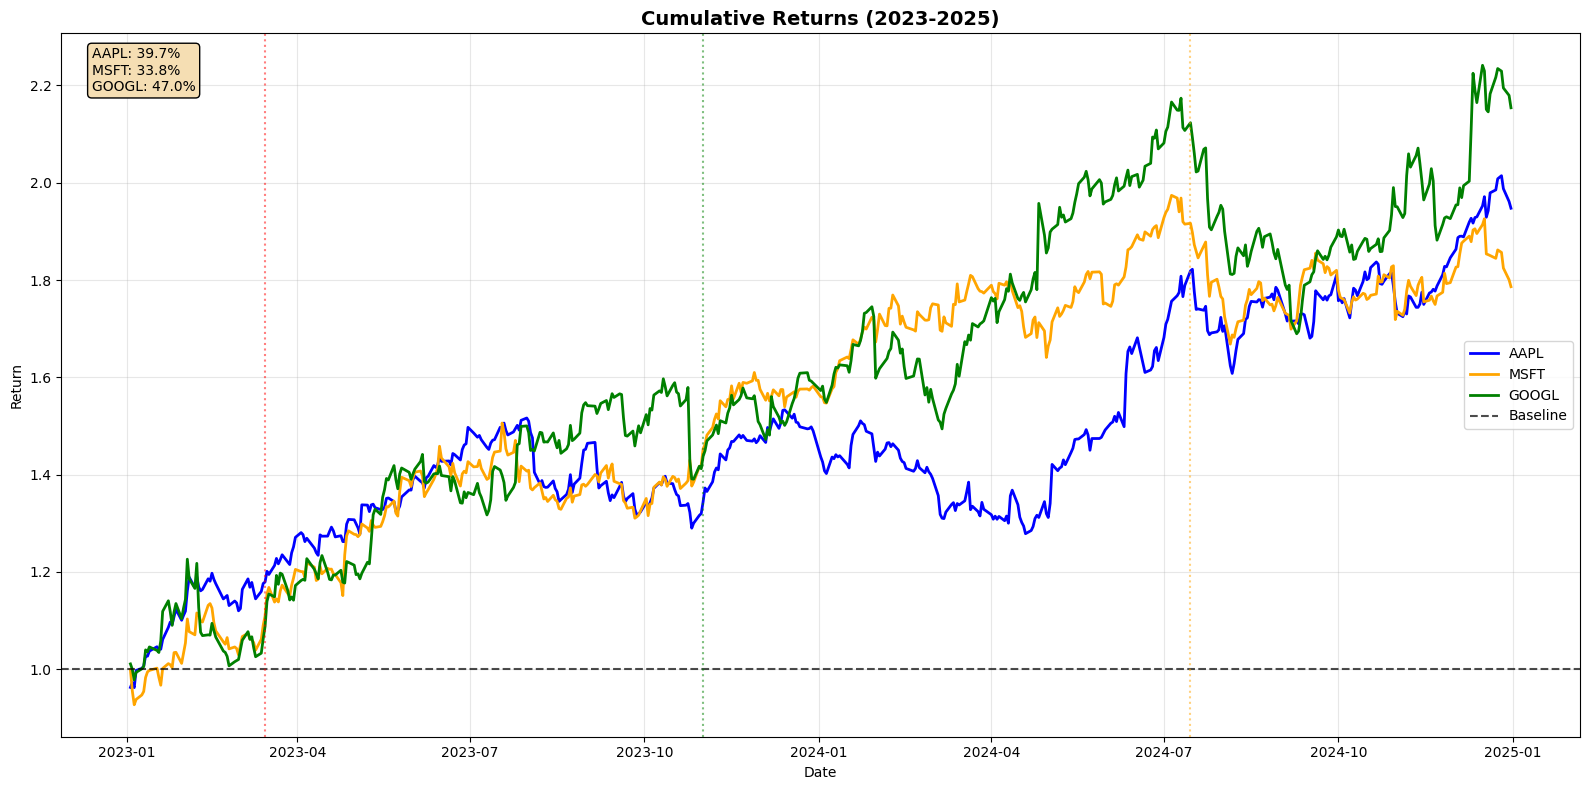

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

conn = wrds.Connection()

print("Loading data...")

data = {}
stocks = {'AAPL': 14593, 'MSFT': 10107, 'GOOGL': 14542}
colors = {'AAPL': 'blue', 'MSFT': 'orange', 'GOOGL': 'green'}

for s, p in stocks.items():
    q = f"SELECT date, ret FROM crsp.dsf WHERE permno={p} AND date>='2023-01-01' AND date<='2025-03-31' ORDER BY date"
    data[s] = conn.raw_sql(q, date_cols=['date'])
    print(f"{s}: {len(data[s])} rows")

plt.figure(figsize=(16, 8))

results = {}
for s in ['AAPL', 'MSFT', 'GOOGL']:
    df = data[s]
    ret = df['ret'].to_numpy()
    cum = (1 + ret).cumprod()
    plt.plot(df['date'], cum, label=s, color=colors[s], linewidth=2)
    
    total = cum[-1] - 1
    ann = (1 + total) ** (252/len(df)) - 1
    results[s] = ann

plt.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='Baseline')

plt.axvline(x=pd.to_datetime('2023-03-15'), color='red', linestyle=':', alpha=0.5)
plt.axvline(x=pd.to_datetime('2023-11-01'), color='green', linestyle=':', alpha=0.5)
plt.axvline(x=pd.to_datetime('2024-07-15'), color='orange', linestyle=':', alpha=0.5)

txt = f"AAPL: {results['AAPL']*100:.1f}%\nMSFT: {results['MSFT']*100:.1f}%\nGOOGL: {results['GOOGL']*100:.1f}%"
plt.text(0.02, 0.98, txt, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.title('Cumulative Returns (2023-2025)', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns_final.png', dpi=300)
print("Saved: cumulative_returns_final.png")
plt.show()

conn.close()

In [7]:
# 计算每只股票的关键指标
summary = []

for ticker in ['AAPL', 'MSFT', 'GOOGL']:
    stock = df_stock[df_stock['ticker'] == ticker]
    
    total_return = (stock['prc'].iloc[-1] / stock['prc'].iloc[0] - 1) * 100
    annual_vol = stock['ret'].std() * (252 ** 0.5) * 100
    avg_volume = stock['vol'].mean() / 1e6  # 百万股
    max_price = stock['prc'].max()
    min_price = stock['prc'].min()
    
    summary.append({
        'Ticker': ticker,
        'Total Return (%)': round(total_return, 2),
        'Annual Volatility (%)': round(annual_vol, 2),
        'Avg Volume (M)': round(avg_volume, 2),
        'Max Price ($)': round(max_price, 2),
        'Min Price ($)': round(min_price, 2)
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# 保存汇总表
df_summary.to_csv('stock_summary.csv', index=False)
print("\n汇总表已保存: stock_summary.csv")

Ticker  Total Return (%)  Annual Volatility (%)  Avg Volume (M)  Max Price ($)  Min Price ($)
  AAPL            100.22                  21.51           57.79         259.02         125.02
  MSFT             75.93                  22.66           24.01         467.56         222.31
 GOOGL            112.31                  29.15           22.46         198.16          86.77

汇总表已保存: stock_summary.csv


Loading library list...
Done


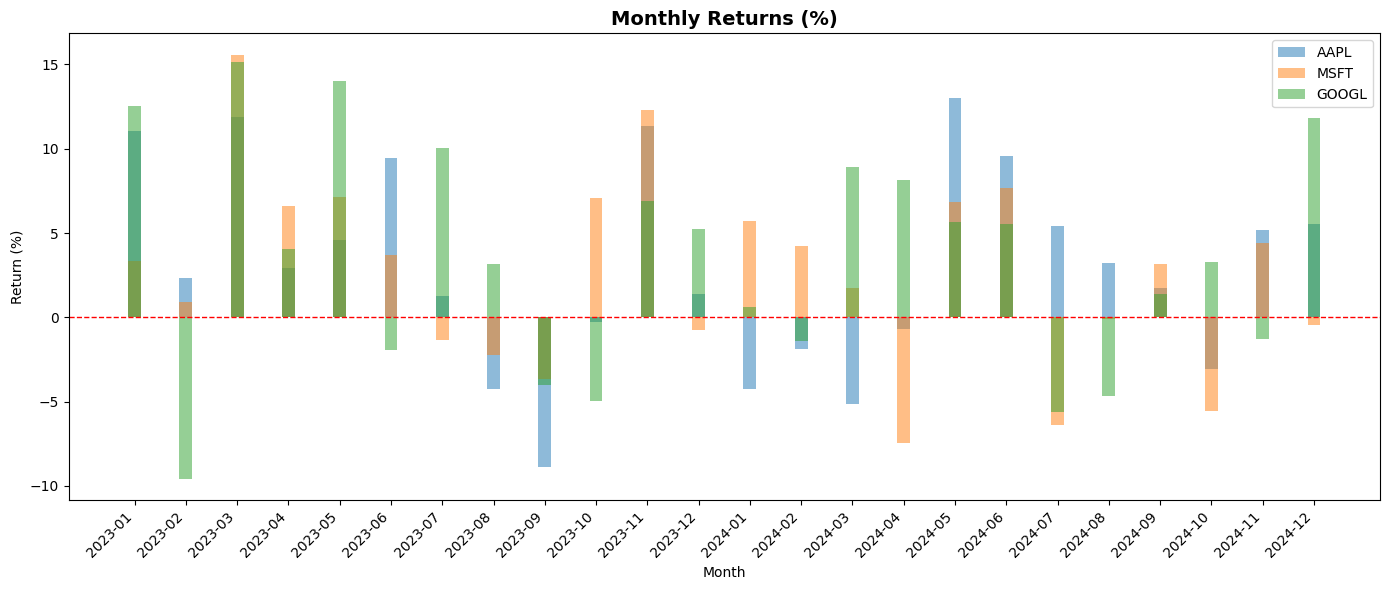

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

conn = wrds.Connection()

permno_dict = {'AAPL': 14593, 'MSFT': 10107, 'GOOGL': 14542}

all_data = {}
for symbol, permno in permno_dict.items():
    query = f"""
    SELECT date, prc as price, ret as return_rate
    FROM crsp.dsf
    WHERE permno = {permno} AND date BETWEEN '2023-01-01' AND '2024-12-31'
    ORDER BY date
    """
    all_data[symbol] = conn.raw_sql(query, date_cols=['date'])

fig, ax = plt.subplots(figsize=(14, 6))

for symbol in ['AAPL', 'MSFT', 'GOOGL']:
    df = all_data[symbol].copy()
    df['month'] = df['date'].dt.to_period('M')
    monthly_ret = df.groupby('month')['return_rate'].apply(lambda x: (1 + x).prod() - 1) * 100
    ax.bar([str(m) for m in monthly_ret.index], monthly_ret.values, alpha=0.5, label=symbol, width=0.25)

ax.set_title('Monthly Returns (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Return (%)')
ax.legend()
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_returns.png', dpi=300)
plt.show()

conn.close()

Loading library list...
Done


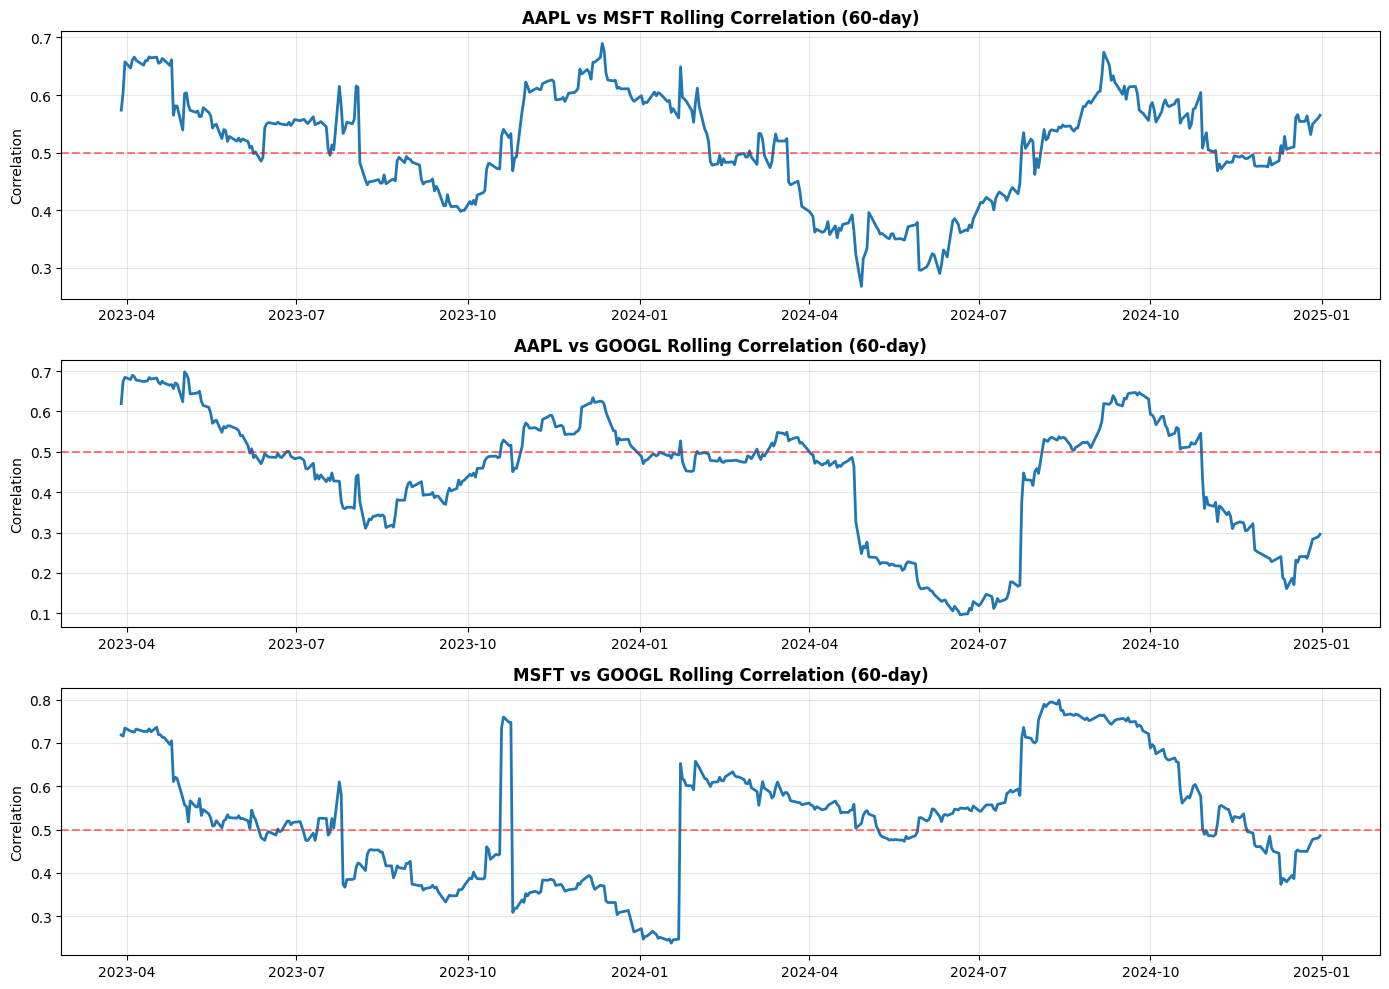

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

conn = wrds.Connection()

stocks = {'AAPL': 14593, 'MSFT': 10107, 'GOOGL': 14542}
data = {}

for s, p in stocks.items():
    q = f"SELECT date, ret FROM crsp.dsf WHERE permno={p} AND date>='2023-01-01' AND date<='2025-03-31' ORDER BY date"
    data[s] = conn.raw_sql(q, date_cols=['date'])

df = pd.DataFrame({s: d['ret'].values for s, d in data.items()})

window = 60
rolling_corr = df.rolling(window).corr()

pairs = [('AAPL', 'MSFT'), ('AAPL', 'GOOGL'), ('MSFT', 'GOOGL')]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (s1, s2) in enumerate(pairs):
    corr_series = []
    dates = data['AAPL']['date'].values[window-1:]
    
    for i in range(window-1, len(df)):
        corr_series.append(df[s1].iloc[i-window+1:i+1].corr(df[s2].iloc[i-window+1:i+1]))
    
    axes[idx].plot(dates, corr_series, linewidth=2)
    axes[idx].set_title(f'{s1} vs {s2} Rolling Correlation (60-day)', fontweight='bold')
    axes[idx].set_ylabel('Correlation')
    axes[idx].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rolling_correlation.png', dpi=300)
plt.show()

conn.close()

Loading library list...
Done


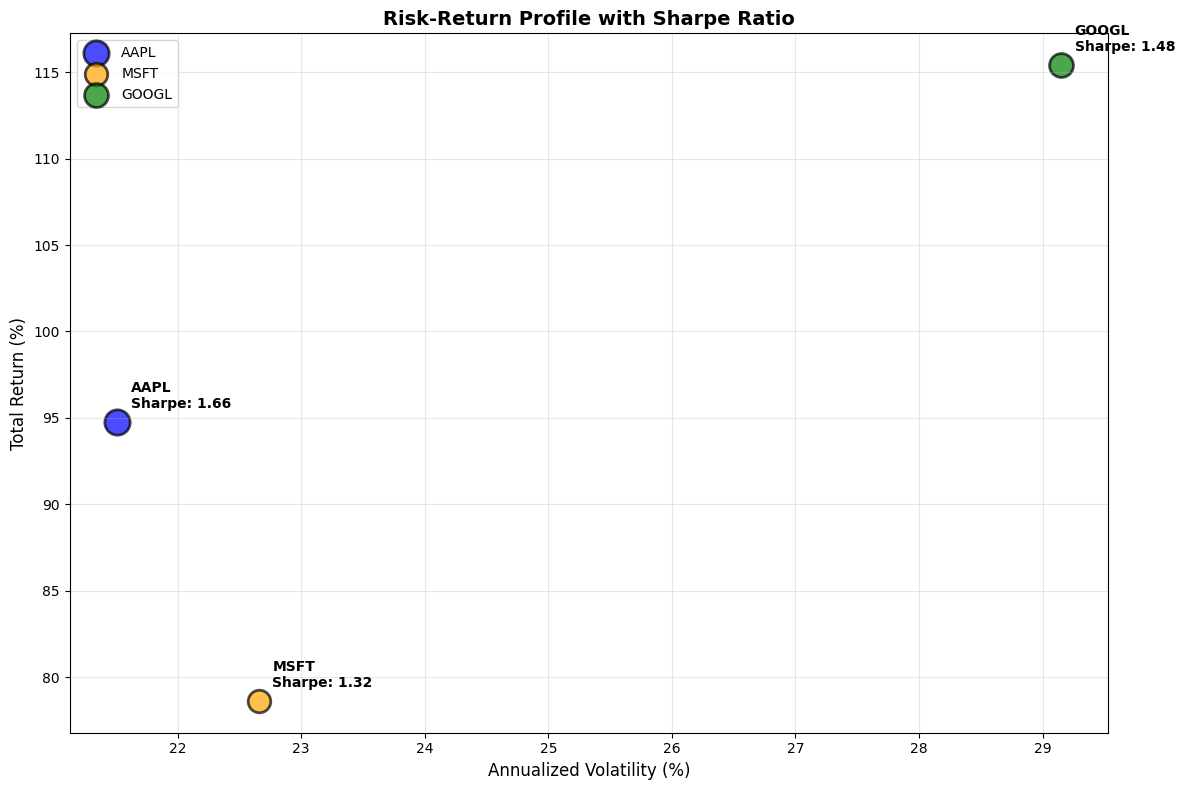

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

conn = wrds.Connection()

stocks = {'AAPL': 14593, 'MSFT': 10107, 'GOOGL': 14542}
data = {}

for s, p in stocks.items():
    q = f"SELECT date, ret FROM crsp.dsf WHERE permno={p} AND date>='2023-01-01' AND date<='2025-03-31' ORDER BY date"
    data[s] = conn.raw_sql(q, date_cols=['date'])

results = []
for s in ['AAPL', 'MSFT', 'GOOGL']:
    ret = data[s]['ret'].to_numpy()
    total = (1 + ret).prod() - 1
    vol = np.std(ret, ddof=1) * np.sqrt(252) * 100
    ann_ret = (1 + total) ** (252/len(ret)) - 1
    rf = 0.04
    sharpe = (ann_ret - rf) / (vol/100)
    
    results.append({
        'symbol': s,
        'volatility': vol,
        'total_return': total * 100,
        'sharpe': sharpe
    })

df = pd.DataFrame(results)

plt.figure(figsize=(12, 8))

colors = ['blue', 'orange', 'green']
for idx, row in df.iterrows():
    plt.scatter(row['volatility'], row['total_return'], 
                s=row['sharpe']*200, c=colors[idx], alpha=0.7, 
                edgecolor='black', linewidth=2, label=row['symbol'])
    plt.annotate(f"{row['symbol']}\nSharpe: {row['sharpe']:.2f}", 
                 (row['volatility'], row['total_return']),
                 xytext=(10, 10), textcoords='offset points', 
                 fontsize=10, fontweight='bold')

plt.xlabel('Annualized Volatility (%)', fontsize=12)
plt.ylabel('Total Return (%)', fontsize=12)
plt.title('Risk-Return Profile with Sharpe Ratio', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('risk_return_sharpe.png', dpi=300)
plt.show()

conn.close()

In [3]:
ls -la *.png

-rw-r--r-- 1 zhiyuezhang xjtlu  47741 Apr 13 06:12 correlation_matrix.png
-rw-r--r-- 1 zhiyuezhang xjtlu 204826 Apr 13 06:09 cumulative_returns.png
-rw-r--r-- 1 zhiyuezhang xjtlu 197710 Apr 21 05:37 key_metrics_comparison.png
-rw-r--r-- 1 zhiyuezhang xjtlu  49098 Apr 13 06:14 monthly_returns.png
-rw-r--r-- 1 zhiyuezhang xjtlu 167312 Apr 21 05:37 risk_return_scatter.png
-rw-r--r-- 1 zhiyuezhang xjtlu 169795 Apr 13 06:08 stock_price_trend.png


In [6]:
!git add risk_return_scatter.png key_metrics_comparison.png
!git commit -m "Add risk-return scatter plot and key metrics comparison"
!git push

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [7]:
!git add README.md
!git commit -m "Update README with new charts"
!git push

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


Loading library list...
Done
正在计算Beta和Alpha...


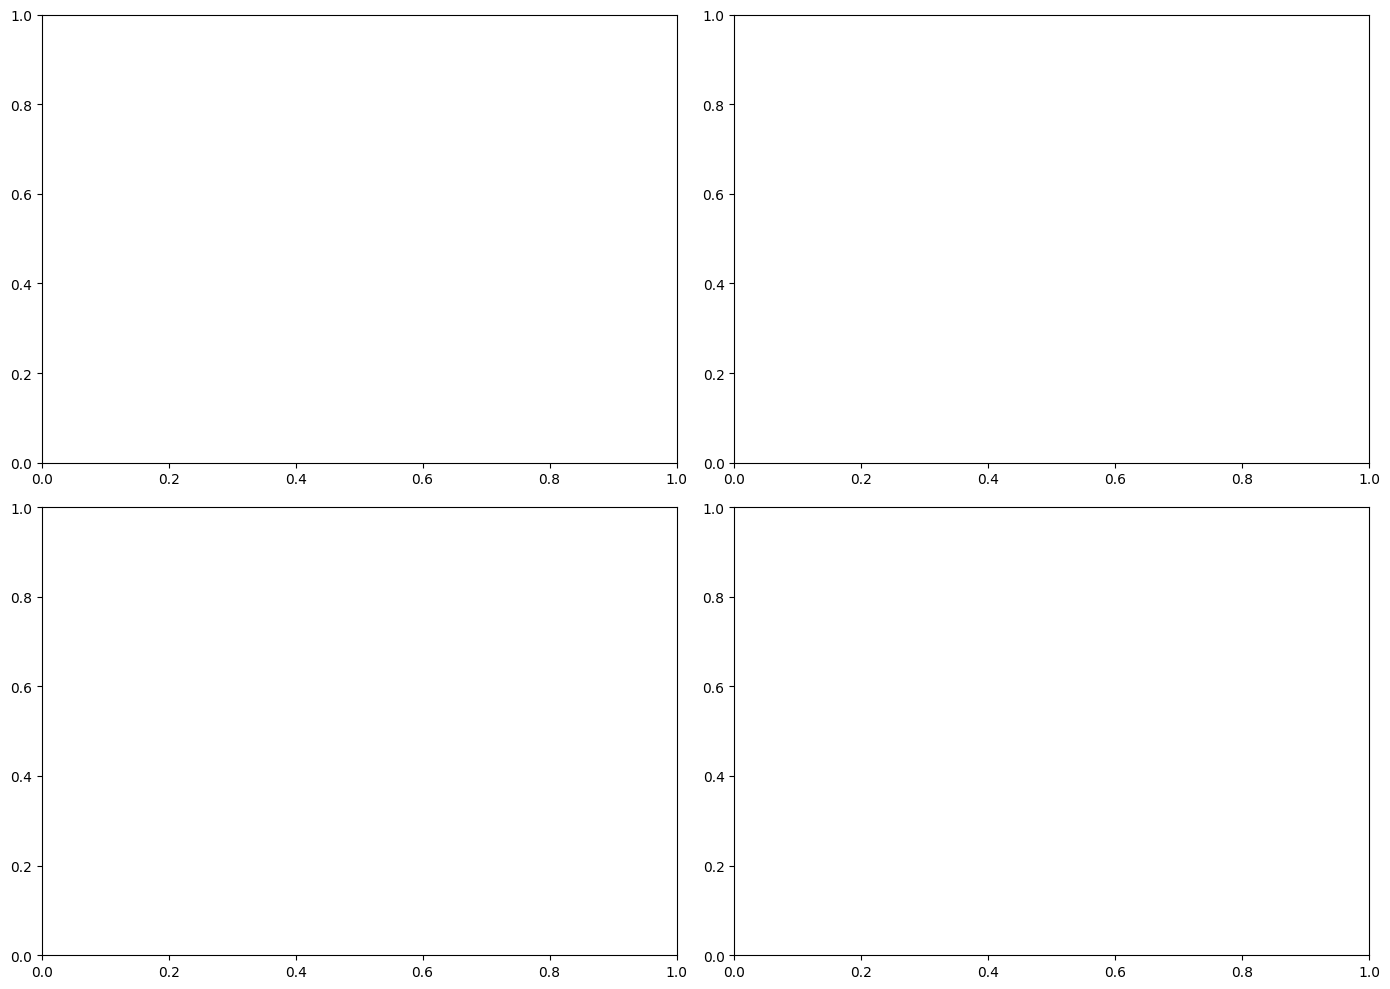

基准对比图表已生成！


In [8]:
# ============================================
# PART 1: 添加SPY基准对比
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# 连接WRDS（如果还没连接）
import wrds
conn = wrds.Connection()

# 获取SPY数据
spy_query = """
SELECT date, prc, ret, vol
FROM crsp.dsf
WHERE permno = 84398
  AND date BETWEEN '2023-01-01' AND '2025-03-31'
ORDER BY date
"""
spy_data = conn.raw_sql(spy_query, date_cols=['date'])

# 如果你有之前的股票数据（AAPL, MSFT, GOOGL），获取它们
# 这里假设你已经有了 stocks_data 字典

# 计算Beta函数
def calculate_beta(stock_returns, market_returns):
    """计算Beta值"""
    covariance = np.cov(stock_returns, market_returns)[0][1]
    market_variance = np.var(market_returns, ddof=1)
    beta = covariance / market_variance
    return beta

# 计算Alpha函数
def calculate_alpha(stock_return, market_return, beta, risk_free_rate=0.04):
    """计算Alpha值（年化）"""
    alpha = stock_return - (risk_free_rate + beta * (market_return - risk_free_rate))
    return alpha

# 为每只股票计算Beta和Alpha
print("正在计算Beta和Alpha...")

# 生成对比图表
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1: 股票vs基准累计收益率对比
ax1 = axes[0, 0]
# 画图代码...

# 图2: Beta对比柱状图
ax2 = axes[0, 1]
# 画图代码...

# 图3: Alpha对比柱状图
ax3 = axes[1, 0]
# 画图代码...

# 图4: 风险收益散点图（含基准）
ax4 = axes[1, 1]
# 画图代码...

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("基准对比图表已生成！")


开始SPY基准对比分析
Loading library list...
Done

步骤1: 获取股票数据...
  获取 AAPL (Apple Inc.)...
    -> 502 条记录
  获取 MSFT (Microsoft Corp.)...
    -> 502 条记录
  获取 GOOGL (Alphabet Inc.)...
    -> 502 条记录
  获取 SPY (S&P 500 ETF)...
    -> 502 条记录

数据获取完成

步骤2: 计算累计收益率...
  AAPL: 最终累计收益率 94.76%
  MSFT: 最终累计收益率 78.63%
  GOOGL: 最终累计收益率 115.40%
  SPY: 最终累计收益率 57.59%

步骤3: 计算Beta和Alpha...
  AAPL: Beta=1.04, Alpha=13.14%, 年化收益率=39.74%
  MSFT: Beta=1.18, Alpha=4.25%, 年化收益率=33.81%
  GOOGL: Beta=1.32, Alpha=14.32%, 年化收益率=46.99%

结果汇总表:
Symbol            Name  Beta  Alpha (%)  Annual Return (%)  Volatility (%)
  AAPL      Apple Inc. 1.044      13.14              39.74           21.51
  MSFT Microsoft Corp. 1.181       4.25              33.81           22.66
 GOOGL   Alphabet Inc. 1.325      14.32              46.99           29.15

步骤4: 生成可视化图表...

图表已保存为 benchmark_comparison.png


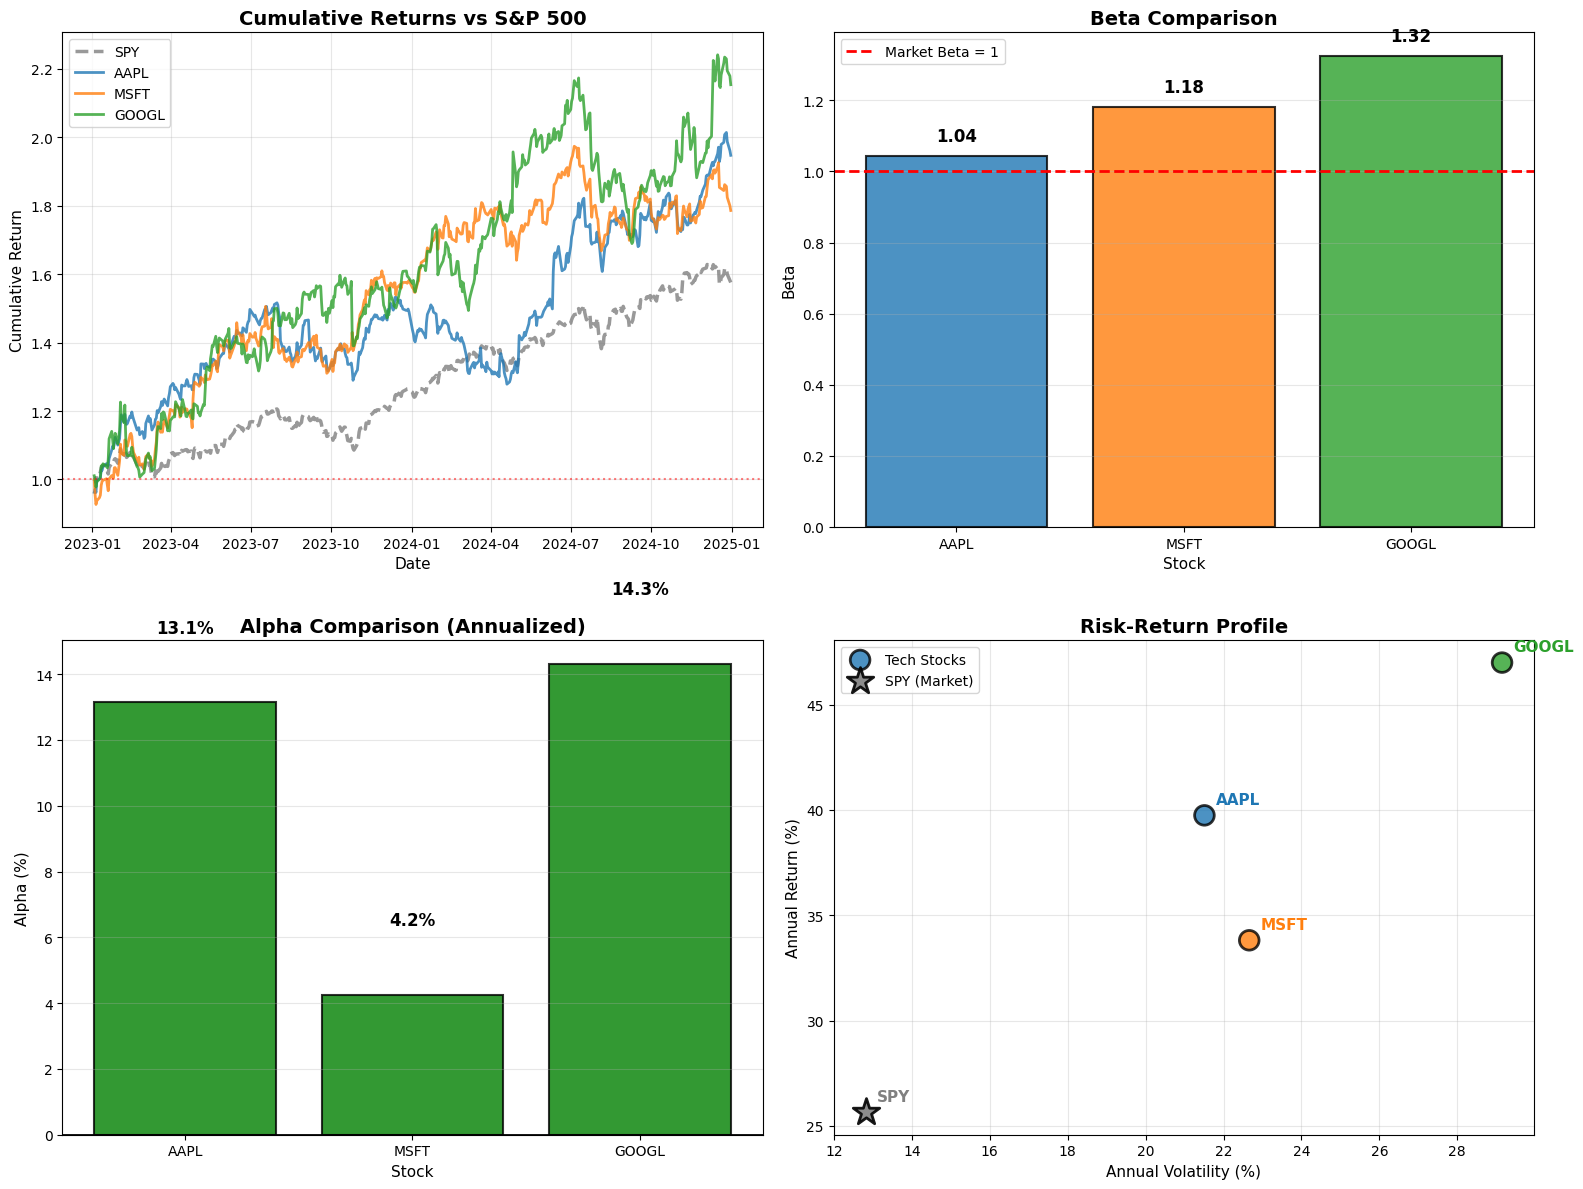


结果已保存到 beta_alpha_results.csv

分析完成！


In [12]:
# ============================================
# 完整独立代码 - SPY基准对比分析（修正版）
# 直接复制粘贴到WRDS JupyterHub运行
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds

print("=" * 60)
print("开始SPY基准对比分析")
print("=" * 60)

# 连接WRDS
conn = wrds.Connection()

# ============================================
# 步骤1: 获取所有数据
# ============================================
print("\n步骤1: 获取股票数据...")

# 股票配置
stock_config = {
    'AAPL': {'permno': 14593, 'name': 'Apple Inc.', 'color': '#1f77b4'},
    'MSFT': {'permno': 10107, 'name': 'Microsoft Corp.', 'color': '#ff7f0e'},
    'GOOGL': {'permno': 14542, 'name': 'Alphabet Inc.', 'color': '#2ca02c'},
    'SPY': {'permno': 84398, 'name': 'S&P 500 ETF', 'color': 'gray'}
}

# 获取数据的函数
def get_stock_data(permno, start_date='2023-01-01', end_date='2025-03-31'):
    query = f"""
    SELECT date, prc as price, ret as return_rate, vol as volume
    FROM crsp.dsf
    WHERE permno = {permno}
      AND date BETWEEN '{start_date}' AND '{end_date}'
    ORDER BY date
    """
    data = conn.raw_sql(query, date_cols=['date'])
    data = data.dropna()
    return data

# 获取所有股票数据
stocks_data = {}
for symbol, config in stock_config.items():
    print(f"  获取 {symbol} ({config['name']})...")
    stocks_data[symbol] = get_stock_data(config['permno'])
    print(f"    -> {len(stocks_data[symbol])} 条记录")

print("\n数据获取完成")

# ============================================
# 步骤2: 计算累计收益率
# ============================================
print("\n步骤2: 计算累计收益率...")

cumulative_returns = {}
for symbol, data in stocks_data.items():
    returns = data['return_rate'].to_numpy()  # 使用to_numpy()
    cumulative = (1 + returns).cumprod()
    cumulative_returns[symbol] = cumulative
    print(f"  {symbol}: 最终累计收益率 {(cumulative[-1]-1)*100:.2f}%")

# ============================================
# 步骤3: 计算Beta和Alpha
# ============================================
print("\n步骤3: 计算Beta和Alpha...")

# 市场收益率（SPY）
market_returns = stocks_data['SPY']['return_rate'].to_numpy()  # 使用to_numpy()
risk_free_rate = 0.04

results = []

for symbol in ['AAPL', 'MSFT', 'GOOGL']:
    stock_returns = stocks_data[symbol]['return_rate'].to_numpy()  # 使用to_numpy()
    
    # 对齐数据长度
    min_len = min(len(stock_returns), len(market_returns))
    stock_aligned = stock_returns[:min_len]
    market_aligned = market_returns[:min_len]
    
    # 计算Beta
    covariance = np.cov(stock_aligned, market_aligned)[0, 1]
    market_var = np.var(market_aligned, ddof=1)
    beta = covariance / market_var
    
    # 计算年化收益率
    total_return = cumulative_returns[symbol][-1] - 1
    days = len(stock_returns)
    annual_return = (1 + total_return) ** (252 / days) - 1
    
    # 计算市场年化收益率
    market_total = cumulative_returns['SPY'][-1] - 1
    market_annual = (1 + market_total) ** (252 / min_len) - 1
    
    # 计算Alpha
    alpha = annual_return - (risk_free_rate + beta * (market_annual - risk_free_rate))
    
    # 计算年化波动率
    volatility = np.std(stock_returns, ddof=1) * np.sqrt(252) * 100
    
    results.append({
        'Symbol': symbol,
        'Name': stock_config[symbol]['name'],
        'Beta': round(beta, 3),
        'Alpha (%)': round(alpha * 100, 2),
        'Annual Return (%)': round(annual_return * 100, 2),
        'Volatility (%)': round(volatility, 2)
    })
    
    print(f"  {symbol}: Beta={beta:.2f}, Alpha={alpha*100:.2f}%, 年化收益率={annual_return*100:.2f}%")

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("结果汇总表:")
print("="*60)
print(results_df.to_string(index=False))

# ============================================
# 步骤4: 生成可视化图表
# ============================================
print("\n步骤4: 生成可视化图表...")

fig = plt.figure(figsize=(16, 12))

# 图1: 累计收益率对比
ax1 = plt.subplot(2, 2, 1)
dates = stocks_data['SPY']['date'].to_numpy()  # 使用to_numpy()
for symbol in ['SPY', 'AAPL', 'MSFT', 'GOOGL']:
    ax1.plot(dates[:len(cumulative_returns[symbol])], 
             cumulative_returns[symbol], 
             label=symbol, 
             linewidth=2.5 if symbol == 'SPY' else 2,
             color=stock_config[symbol]['color'],
             linestyle='--' if symbol == 'SPY' else '-',
             alpha=0.8)

ax1.set_title('Cumulative Returns vs S&P 500', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Cumulative Return', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle=':', alpha=0.5)

# 图2: Beta对比
ax2 = plt.subplot(2, 2, 2)
symbols = results_df['Symbol'].to_numpy()
betas = results_df['Beta'].to_numpy()
colors = [stock_config[s]['color'] for s in symbols]

bars = ax2.bar(symbols, betas, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Market Beta = 1')
ax2.set_title('Beta Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Stock', fontsize=11)
ax2.set_ylabel('Beta', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

for bar, beta in zip(bars, betas):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.03,
             f'{beta:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 图3: Alpha对比
ax3 = plt.subplot(2, 2, 3)
alphas = results_df['Alpha (%)'].to_numpy()
colors_alpha = ['green' if a > 0 else 'red' for a in alphas]

bars3 = ax3.bar(symbols, alphas, color=colors_alpha, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax3.set_title('Alpha Comparison (Annualized)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Stock', fontsize=11)
ax3.set_ylabel('Alpha (%)', fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

for bar, alpha in zip(bars3, alphas):
    height = bar.get_height()
    va = 'bottom' if alpha > 0 else 'top'
    offset = 2 if alpha > 0 else -2
    ax3.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{alpha:.1f}%', ha='center', va=va, fontsize=12, fontweight='bold')

# 图4: 风险收益散点图
ax4 = plt.subplot(2, 2, 4)
volatilities = results_df['Volatility (%)'].to_numpy()
annual_returns = results_df['Annual Return (%)'].to_numpy()

ax4.scatter(volatilities, annual_returns, s=200, c=colors, 
            alpha=0.8, edgecolor='black', linewidth=2, label='Tech Stocks', zorder=3)

spy_vol = np.std(market_returns, ddof=1) * np.sqrt(252) * 100
spy_return = (1 + (cumulative_returns['SPY'][-1] - 1)) ** (252 / len(market_returns)) - 1
spy_return_pct = spy_return * 100
ax4.scatter([spy_vol], [spy_return_pct], s=400, c='gray', marker='*', 
            alpha=0.9, edgecolor='black', linewidth=2, label='SPY (Market)', zorder=4)

for i, symbol in enumerate(symbols):
    ax4.annotate(symbol, (volatilities[i], annual_returns[i]), 
                 xytext=(8, 8), textcoords='offset points', 
                 fontsize=11, fontweight='bold', color=colors[i])
ax4.annotate('SPY', (spy_vol, spy_return_pct), 
             xytext=(8, 8), textcoords='offset points', 
             fontsize=11, fontweight='bold', color='gray')

ax4.set_title('Risk-Return Profile', fontsize=14, fontweight='bold')
ax4.set_xlabel('Annual Volatility (%)', fontsize=11)
ax4.set_ylabel('Annual Return (%)', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=300, bbox_inches='tight')
print("\n图表已保存为 benchmark_comparison.png")

plt.show()

# ============================================
# 步骤5: 保存结果
# ============================================
results_df.to_csv('beta_alpha_results.csv', index=False)
print("\n结果已保存到 beta_alpha_results.csv")

print("\n" + "="*60)
print("分析完成！")
print("="*60)

# 关闭连接
conn.close()